### Unit Quality Metrics
reference
- https://allensdk.readthedocs.io/en/latest/_static/examples/nb/ecephys_quality_metrics.html

![isi_violation](../docs/img/isi_violation.png)
![presence_ratio](../docs/img/presence_ratio.png)
![amplitude_cutoff](../docs/img/amplitude_cutoff.png)

In [1]:
import os
from datetime import datetime
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import csv
import pickle
import libs.utils as utils
import libs.handle.dataset as handle_dataset
import spikeinterface as si


c:\Users\shoya\code\tamagawa-neuro-training-shysgmt\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# histogram smoothing
from scipy.ndimage.filters import gaussian_filter1d
plt.rcParams.update({'font.size': 14})

def plot_metric(data, bins, x_axis_label, color, max_value=-1):
    
    h, b = np.histogram(data, bins=bins, density=True)

    x = b[:-1]
    y = gaussian_filter1d(h, 1)

    plt.plot(x, y, color=color)
    plt.xlabel(x_axis_label)
    plt.gca().get_yaxis().set_visible(False)
    [plt.gca().spines[loc].set_visible(False) for loc in ['right', 'top', 'left']]
    if max_value < np.max(y) * 1.1:
        max_value = np.max(y) * 1.1
    plt.ylim([0, max_value])
    
    return max_value

C:\Users\shoya\AppData\Local\Temp\ipykernel_26268\823860682.py:2: DeprecationWarning: Please import `gaussian_filter1d` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter1d


In [3]:
# Root directory for all data in the session
session_dir = r"E:\tamagawa-neuro-training-2026\RSS060_260817_164455"

In [4]:
# Get the session oject
session = handle_dataset.Session(session_dir)

In [5]:
# Extract dataset of target probe
i_imec = 0
folder_name = 'sorting_analyzer_dredge'
session.add_sorting_analyzer(i_imec=i_imec, folder_name=folder_name)

Loading sorting_analyzer from E:\tamagawa-neuro-training-2026\RSS060_260817_164455\spikeinterface\imec0\sorting_analyzer_dredge


In [6]:
# load metrics.csv
base_dir = session.sorting_analyzer_base_dir
path = os.path.join(base_dir, 'extensions', 'quality_metrics', 'metrics.csv')
metrics = pd.read_csv(path, index_col=0)
metrics

,firing_rate,presence_ratio,snr,isi_violations_ratio,isi_violations_count,rp_contamination,rp_violations,sliding_rp_violation,amplitude_cutoff,amplitude_median,amplitude_cv_median,amplitude_cv_range
0,3.041084,1.000000,1.580627,1.020652,51.0,1.000000,25.0,NaN,0.000047,-14.310759,0.838531,1.161411
1,3.078286,1.000000,3.712071,0.507832,26.0,0.194752,6.0,0.200,0.000984,-34.328094,0.406404,0.359453
2,10.642962,1.000000,4.465568,0.459141,281.0,0.292886,102.0,0.265,0.000329,-39.125473,NaN,NaN
3,10.534134,1.000000,3.558502,0.361932,217.0,0.206445,74.0,0.195,0.000014,-30.728964,NaN,NaN
4,4.132699,1.000000,2.993207,0.270917,25.0,0.121120,7.0,0.155,0.000443,-25.891195,0.545519,0.309420
...,...,...,...,...,...,...,...,...,...,...,...,...
710,7.466398,0.533333,1.009780,7.735674,2330.0,1.000000,1545.0,NaN,0.000318,-7.974987,NaN,NaN
711,1.797888,1.000000,3.106455,0.629843,11.0,0.089931,1.0,0.200,0.000215,-28.289600,NaN,NaN
712,1.064407,1.000000,2.168498,1.143528,7.0,0.859170,2.0,NaN,0.000135,-19.836746,0.774720,0.925874
713,2.413101,0.600000,0.943891,2.320259,73.0,1.000000,37.0,NaN,0.000228,-11.823963,NaN,NaN


<Axes: xlabel='firing_rate', ylabel='Count'>

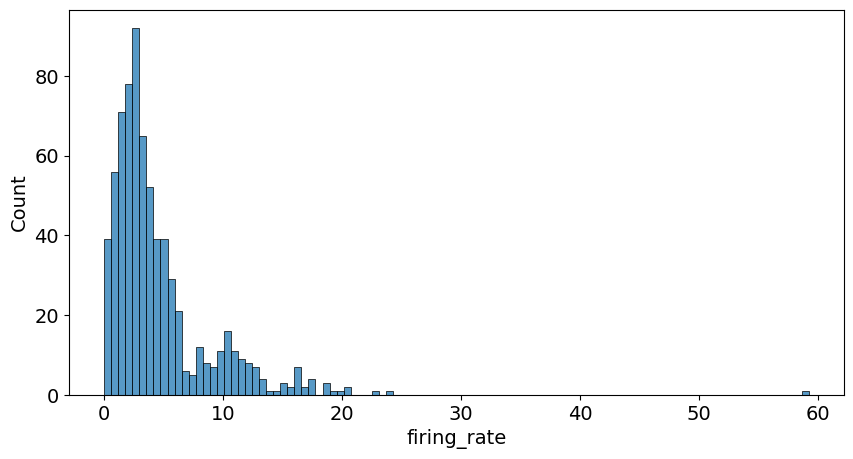

In [7]:
# plot histogram
bins = np.arange(0, 5, 0.5)
bins = 100

data = metrics['firing_rate']

plt.figure(figsize=(10, 5))    
sns.histplot(
    data=data, 
    bins=bins,
)

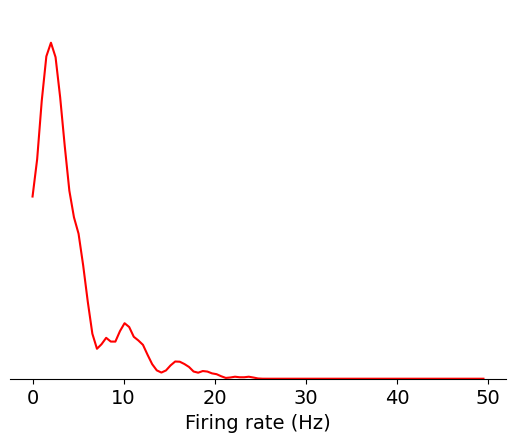

In [8]:
# plot histogram with gaussian smoothing
data = metrics['firing_rate']
bins = np.linspace(0,50,100)

max_value = plot_metric(data, bins, 'Firing rate (Hz)', 'red')

In [11]:
# load unit_location.npy
base_dir = session.sorting_analyzer_base_dir
path = os.path.join(base_dir, 'extensions', 'unit_locations', 'unit_locations.npy')
temp = np.load(path, allow_pickle=True).tolist()
unit_locations = pd.DataFrame(temp, columns=['x', 'y', 'z'])
unit_locations

,x,y,z
0,15.128237,97.625514,45.787166
1,42.865588,43.623403,101.109105
2,40.947056,128.813655,191.959020
3,26.465956,134.857763,180.818791
4,191.377612,-8.064092,150.068209
...,...,...,...
710,29.084600,7539.501653,1.354854
711,-38.054856,-110.702662,980.380495
712,-343.075451,-185.587610,908.085227
713,25.363447,7580.145375,2.136451


In [16]:
# concat metrics and unit_locations
unit_infomation = metrics.join(unit_locations)
unit_infomation

,firing_rate,presence_ratio,snr,isi_violations_ratio,isi_violations_count,rp_contamination,rp_violations,sliding_rp_violation,amplitude_cutoff,amplitude_median,amplitude_cv_median,amplitude_cv_range,x,y,z
0,3.041084,1.000000,1.580627,1.020652,51.0,1.000000,25.0,NaN,0.000047,-14.310759,0.838531,1.161411,15.128237,97.625514,45.787166
1,3.078286,1.000000,3.712071,0.507832,26.0,0.194752,6.0,0.200,0.000984,-34.328094,0.406404,0.359453,42.865588,43.623403,101.109105
2,10.642962,1.000000,4.465568,0.459141,281.0,0.292886,102.0,0.265,0.000329,-39.125473,NaN,NaN,40.947056,128.813655,191.959020
3,10.534134,1.000000,3.558502,0.361932,217.0,0.206445,74.0,0.195,0.000014,-30.728964,NaN,NaN,26.465956,134.857763,180.818791
4,4.132699,1.000000,2.993207,0.270917,25.0,0.121120,7.0,0.155,0.000443,-25.891195,0.545519,0.309420,191.377612,-8.064092,150.068209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
710,7.466398,0.533333,1.009780,7.735674,2330.0,1.000000,1545.0,NaN,0.000318,-7.974987,NaN,NaN,29.084600,7539.501653,1.354854
711,1.797888,1.000000,3.106455,0.629843,11.0,0.089931,1.0,0.200,0.000215,-28.289600,NaN,NaN,-38.054856,-110.702662,980.380495
712,1.064407,1.000000,2.168498,1.143528,7.0,0.859170,2.0,NaN,0.000135,-19.836746,0.774720,0.925874,-343.075451,-185.587610,908.085227
713,2.413101,0.600000,0.943891,2.320259,73.0,1.000000,37.0,NaN,0.000228,-11.823963,NaN,NaN,25.363447,7580.145375,2.136451


<Axes: xlabel='firing_rate', ylabel='y'>

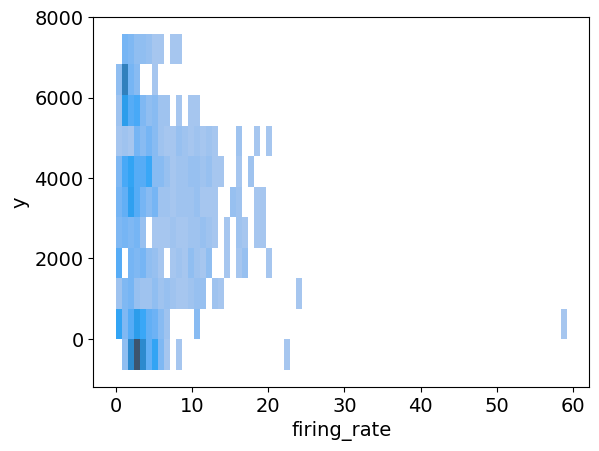

In [17]:
df = unit_infomation.copy()

sns.histplot(
    data=df,
    x='firing_rate',
    y='y',
)

<Axes: xlabel='firing_rate', ylabel='y'>

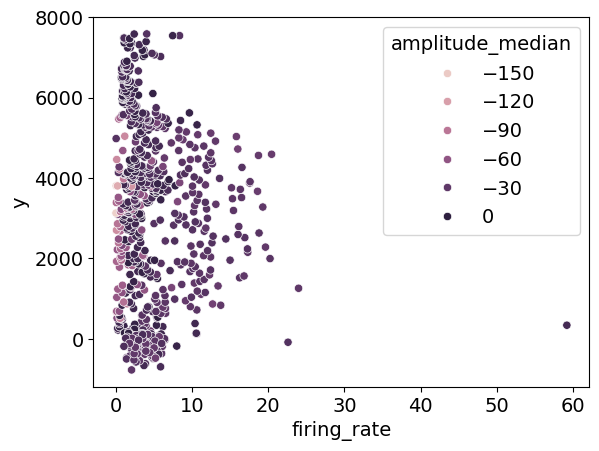

In [21]:
df = unit_infomation.copy()

sns.scatterplot(
    data=df,
    x='firing_rate',
    y='y',
    hue='amplitude_median',
)